## Generalized Linear Model

### Likelihood (transconjugants)

For each experiment \(i\), replica \(j\), within-replica observation \(k\), and condition \(c\),

$$
T_{i,j,k,c}\mid \lambda_{i,j,c},\,X_{i,c},\,\rho_k
\;\overset{\text{ind}}{\sim}\;
\text{Poisson}\!\big(\rho_k\,\lambda_{i,j,c}\big),
$$

with

$$
\lambda_{i,j,c}=\alpha_i\,\theta_{i,j,c}.
$$

### Indices and variables

- \(i \in \{1,\dots,10\}\): experiment  
- \(j \in \{A,B,C\}\): experiment replica  
- \(k \in \{1,\dots,9\}\): observations within each replica  
- \(c \in \{-1,1\}\): control (\(c=-1\)) or treatment (\(c=+1\))  
- \(T_{i,j,k,c}\): transconjugant count  
- \(X_{i,c}\): covariate vector (Temp, \([\mathrm{IBU}]\), \([\mathrm{DMSO}]\)) for experiment \(i\) under condition \(c\)  
- \(\rho_k = 10^{-\lceil k/3\rceil}\): dilution factor for transconjugant measurements  
- \(\alpha_i\): donor count (exposure) for experiment \(i\)  
- \(\theta_{i,j,c}\): transconjugation rate per donor  

---

## Linear predictor (log link)

We model \(\lambda_{i,j,c}\) using a log link with an exposure offset:

$$
\log(\lambda_{i,j,c})
=
\log(\alpha_i)
+ b_{i,j}
+ \boldsymbol{\beta}^{\top}F(\mathbf{x}_{i,c}).
$$

- \(\mathbf{x}_{i,c}\): raw covariates for experiment \(i\), condition \(c\)  
- \(F(\mathbf{x}_{i,c})\): feature map (e.g., main effects, interactions, transformations)  
- \(\boldsymbol{\beta}\in\mathbb{R}^p\): fixed-effect coefficients  

### Random effect (replica-level)

$$
b_{i,j}\mid \sigma_b^2
\;\overset{\text{iid}}{\sim}\;
\mathcal{N}(0,\sigma_b^2).
$$

---

## Bayesian model for donors

### Likelihood (donor measurements)

For donor count measurements indexed by \(k\),

$$
D_{i,k}\mid \alpha_i,\,\delta_k
\;\overset{\text{ind}}{\sim}\;
\text{Poisson}\!\big(\delta_k\,\alpha_i\big),
$$

where

- \(D_{i,k}\): donor count measurement for experiment \(i\)  
- \(\delta_k = 10^{-5-\lceil k/3\rceil}\): dilution factor for donor measurements  

---

## Priors

### Donor-level prior

$$
\log(\alpha_i)\mid \mu_\alpha,\,\sigma_\alpha^2
\;\overset{\text{iid}}{\sim}\;
\mathcal{N}(\mu_\alpha,\sigma_\alpha^2).
$$

### Hyperpriors for donor parameters

$$
\mu_\alpha \sim \mathcal{N}(\mu_{\alpha_0},\sigma_{\alpha_0}^2),
\qquad
\sigma_\alpha \sim \text{half-}\mathcal{N}(0,s_{\alpha_0}).
$$

### Priors for fixed effects

$$
\boldsymbol{\beta}\mid \tau
\sim
\mathcal{N}\!\big(\mathbf{0},\,\tau^2 I_p\big),
\qquad
\tau \sim \text{half-}\mathcal{N}(0,1).
$$

### Prior for random-effect variance

$$
\sigma_b^2 \sim \text{Inverse-Gamma}(2,1).
$$

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions



import os
from pathlib import Path

# Find and navigate to Progetto_Bayesian_Statistics
current = Path.cwd()

# Check if we're already there
if current.name == 'Progetto_Bayesian_Statistics':
    print(f"Already in project root: {current}")
else:
    # Search up to parent directories
    for parent in [current] + list(current.parents):
        if parent.name == 'Progetto_Bayesian_Statistics':
            os.chdir(parent)
            print(f"Changed to: {parent}")
            break
    else:
        raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

# Verify
assert Path('src').exists(), "src/ folder not found"
print(f"Current directory: {os.getcwd()}")
print(f"Contents: {os.listdir()}")


# Create ./stan folder if does not exists
STAN_PATH = "./src/stan_models/"
import cmdstanpy
print(cmdstanpy.cmdstan_path())

Already in project root: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Current directory: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Contents: ['.git', '.gitignore', 'requirements.bk.txt', 'README.md', 'data', 'requirements.txt', 'materials', 'src']
/home/ahbagheri/.cmdstan/cmdstan-2.38.0


In [4]:
#loading data
#get the data
data=pd.read_csv("./data/data.csv")
data_donors=pd.read_csv("./data/data_donatori.csv")
data=data[data['Conta']!='TMTC']
data_donors=data_donors[data_donors['Conta']!='TMTC']
#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Conta':'Count'}, inplace=True)

#Modify values in some columns:
#Modify Idx Experiment such that experiments 5 and 6 have the same idx, experiments 7 and 8, experiment 5,6 has the same index as 5 and 6 and experiment 7,8 the same as 7 and 8
#but first convert all to string to avoid problems with mixed types
data['Idx Experiment'] = data['Idx Experiment'].astype(str)
data['Idx Experiment'] = data['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})
#now reconvert to numeric
data['Idx Experiment'] = pd.to_numeric(data['Idx Experiment'])

data_donors['Idx Experiment'] = data_donors['Idx Experiment'].astype(str)
data_donors['Idx Experiment'] = data_donors['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})

#modify control column: convert 'Yes' to 1 and 'No' to 0
data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})



#now reconvert to numeric
data_donors['Idx Experiment'] = pd.to_numeric(data_donors['Idx Experiment'])

print(data['Idx Experiment'].unique())
print(data_donors['Idx Experiment'].unique())

#convert to numeric all the others columns I need 
#convert A;B;C in 1;2;3
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].astype(str)
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].replace({'A': '1', 'B':'2','C': '3'})
#now reconvert to numeric
data['Idx Replica Experiment'] = pd.to_numeric(data['Idx Replica Experiment'])

data['Count'] = pd.to_numeric(data['Count'])
data['Idx Replica Diluition'] = pd.to_numeric(data['Idx Replica Diluition'])
data['Diluition'] = pd.to_numeric(data['Diluition'])
data['IBU'] = pd.to_numeric(data['IBU'])
data['DMSO'] = pd.to_numeric(data['DMSO'])
data['Temp'] = pd.to_numeric(data['Temp'])
data_donors['Count'] = pd.to_numeric(data_donors['Count'])
data_donors['Idx Replica Experiment'] = pd.to_numeric(data_donors['Idx Replica Experiment'])  

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/tmp/ipykernel_38233/3506374784.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


# Priors:
R2D2: https://arxiv.org/pdf/1609.00046

In [5]:
#Extract the data we need for the Stan model 
#from trasconjugant dataset
Y=data.Count.values
N=len(Y)
idx_experiment=data['Idx Experiment'].values
I=len(np.unique(idx_experiment))
idx_experiment_replica=data['Idx Replica Experiment'].values
J=len(np.unique(idx_experiment_replica))
dil_trasc=data['Diluition'].values
rho_trasc = np.power(10.0, dil_trasc)


#from donor dataset
D=data_donors.Count.values
M=len(D)
idx_donor_experiment=data_donors['Idx Experiment'].values
dil_donor=data_donors['Diluition'].values
rho_donor=np.power(10.0, dil_donor)


#build design matrix X
IBU=data['IBU'].values
DMSO=data['DMSO'].values
Temp=data['Temp'].values

#normalize covariates
IBU=(IBU - np.mean(IBU)) / np.std(IBU)
DMSO=(DMSO - np.mean(DMSO)) / np.std(DMSO)
Temp=(Temp - np.mean(Temp)) / np.std(Temp)  

X = np.column_stack([np.ones_like(Y),IBU,DMSO,Temp])
# model_names = {"ab_baseline_simple_poi.stan": {}, "ab_regularized_horseshoe1.stan": {"p0":1}, "ab_regularized_horseshoe2.stan": {"p0":2}, "ab_regularized_horseshoe3.stan": {"p0":3}, "ab_lasso.stan": {}, "ab_horseshoe.stan": {}, "ab_r2d2.stan": {"R2_mean": 0.5,"R2_prec": 2.0, "cons_D2": 0.5}}
model_names = {"ab_baseline_simple_poi.stan": {}, "ab_regularized_horseshoe2.stan": {"p0":2}, "ab_r2d2.stan": {"R2_mean": 0.5,"R2_prec": 2.0, "cons_D2": 0.5}}

models = {}
for key in model_names:
    print(f"Compiling model: {key}")
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key}")
    models[key] = {"model": glm}

Compiling model: ab_baseline_simple_poi.stan
Compiling model: ab_regularized_horseshoe2.stan
Compiling model: ab_r2d2.stan


In [6]:
# Input data
glm_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X.shape[1],
    "Y": Y,
    "D": D,
    "X": X,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}


for key in model_names:
    new_data = glm_data.copy()
    new_data.update(model_names[key])
    print(f"Compiling model: {key}")
    models[key]["data"] = new_data

# # sample from all:
# for key in models:
#     print(f"Sampling model: {key}")
#     glm_fit = models[key]["model"].sample(data=models[key]["data"], chains=4, parallel_chains=4, 
#                                  iter_warmup=1000, iter_sampling=5000,show_console=False)
#     models[key]["fit"] = glm_fit

# for key in models:
#     models[key]["az"] = az.from_cmdstanpy(models[key]["fit"])

Compiling model: ab_baseline_simple_poi.stan
Compiling model: ab_regularized_horseshoe2.stan
Compiling model: ab_r2d2.stan


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def sample_model(key, model_config, sample_config):
    glm_fit = model_config["model"].sample(
        data=model_config["data"], 
        **sample_config
    )
    return key, glm_fit


sample_config = {
    "chains": 4,  
    "parallel_chains": 4,
    "iter_warmup": 1200, 
    "iter_sampling": 5500,
    "show_console": True,
    "adapt_delta": 0.99,  # increase from 0.8
    "max_treedepth": 12, 
}


max_workers = 5
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(sample_model, k, v, sample_config): k 
        for k, v in models.items()
    }
    for future in as_completed(futures):
        key, fit = future.result()
        models[key]["fit"] = fit
        models[key]["az"] = az.from_cmdstanpy(fit)
        print(f"✓ Completed: {key}")

print("\n✓ All models fitted")

20:00:13 - cmdstanpy - INFO - Chain [1] start processing
20:00:13 - cmdstanpy - INFO - Chain [2] start processing
20:00:13 - cmdstanpy - INFO - Chain [3] start processing


20:00:13 - cmdstanpy - INFO - Chain [4] start processing
20:00:13 - cmdstanpy - INFO - Chain [1] start processing
20:00:13 - cmdstanpy - INFO - Chain [2] start processing
20:00:13 - cmdstanpy - INFO - Chain [3] start processing
20:00:13 - cmdstanpy - INFO - Chain [4] start processing
20:00:13 - cmdstanpy - INFO - Chain [1] start processing
20:00:13 - cmdstanpy - INFO - Chain [2] start processing
20:00:13 - cmdstanpy - INFO - Chain [3] start processing
20:00:13 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5500
Chain [1] num_warmup = 1200
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 5500
Chain [2] num_warmup = 1200
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 12
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1]

20:02:42 - cmdstanpy - INFO - Chain [4] done processing


Chain [1] Iteration: 4800 / 6700 [ 71%]  (Sampling)
Chain [1] Iteration: 4400 / 6700 [ 65%]  (Sampling)
Chain [2] Iteration: 3800 / 6700 [ 56%]  (Sampling)
Chain [4] Iteration: 4900 / 6700 [ 73%]  (Sampling)
Chain [4] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 26.718 seconds (Warm-up)
Chain [4] 119.478 seconds (Sampling)
Chain [4] 146.196 seconds (Total)
Chain [4] 
Chain [4] 
Chain [2] Iteration: 6300 / 6700 [ 94%]  (Sampling)
Chain [3] Iteration: 5700 / 6700 [ 85%]  (Sampling)
Chain [1] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [4] Iteration: 5600 / 6700 [ 83%]  (Sampling)
Chain [3] Iteration: 5700 / 6700 [ 85%]  (Sampling)
Chain [3] Iteration: 5500 / 6700 [ 82%]  (Sampling)
Chain [2] Iteration: 3500 / 6700 [ 52%]  (Sampling)
Chain [4] Iteration: 5000 / 6700 [ 74%]  (Sampling)
Chain [1] Iteration: 4500 / 6700 [ 67%]  (Sampling)
Chain [2] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [1] Iteration: 4900 / 6700 [ 73%]  (Sampling)
Chain [3] Itera

...

Chain [2] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 42.01 seconds (Warm-up)
Chain [2] 181.728 seconds (Sampling)
Chain [2] 223.738 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] Iteration: 6600 / 6700 [ 98%]  (Sampling)


20:04:03 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 21 divergent transitions (0.4%)
	Chain 2 had 23 divergent transitions (0.4%)
	Chain 3 had 19 divergent transitions (0.3%)
	Chain 4 had 13 divergent transitions (0.2%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
20:04:04 - cmdstanpy - INFO - Chain [2] done processing
20:04:04 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: cauchy_lpdf: Scale parameter is inf, but must be positive finite! (in 'ab_regularized_horseshoe2.stan', line 67, column 4 to column 57)
Exception: ab_regularized_horseshoe2_model_namespace::log_prob: lambda_tilde[1] is -nan, but must be greater than or equal to 0.000000 (in 'ab_regularized_horseshoe2.stan', line 38, column 4 to column 36)
	Exception: ab_regularized_horseshoe2_model_namespace::log_prob: lambda_tilde[1] is -nan, but must be greater than or equal to 0.000000 (in 'ab_regularized_horseshoe2.stan', line 38, column

Chain [2] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [2] 
Chain [2]  Elapsed Time: 62.563 seconds (Warm-up)
Chain [2]                163.947 seconds (Sampling)
Chain [2]                226.51 seconds (Total)
Chain [2] 
Chain [2] 
✓ Completed: ab_r2d2.stan


20:04:06 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 35 divergent transitions (0.6%)
	Chain 2 had 22 divergent transitions (0.4%)
	Chain 3 had 45 divergent transitions (0.8%)
	Chain 4 had 40 divergent transitions (0.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


✓ Completed: ab_regularized_horseshoe2.stan

✓ All models fitted


In [8]:
for key in models:
    poi_glm_data = models[key]["az"]
    print("divergence of ",key,np.sum(poi_glm_data.sample_stats.diverging))

divergence of  ab_baseline_simple_poi.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ab_regularized_horseshoe2.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(142)
divergence of  ab_r2d2.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(76)


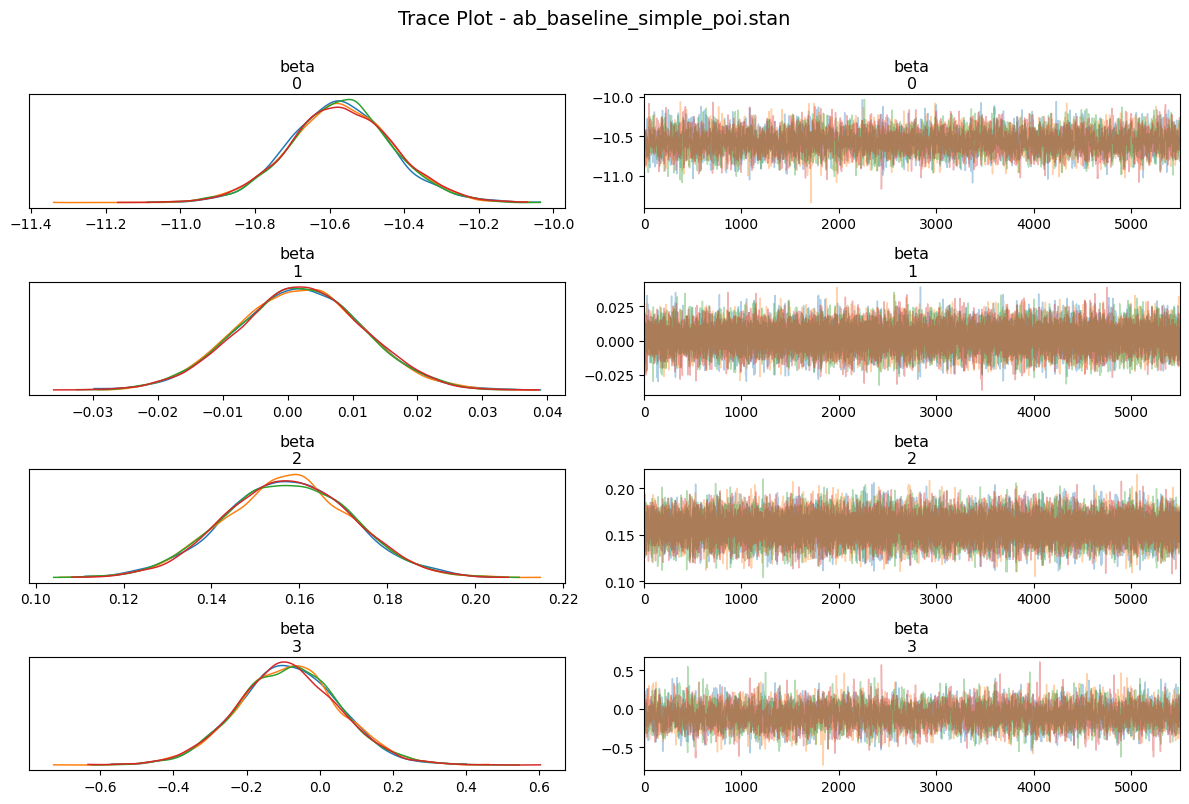

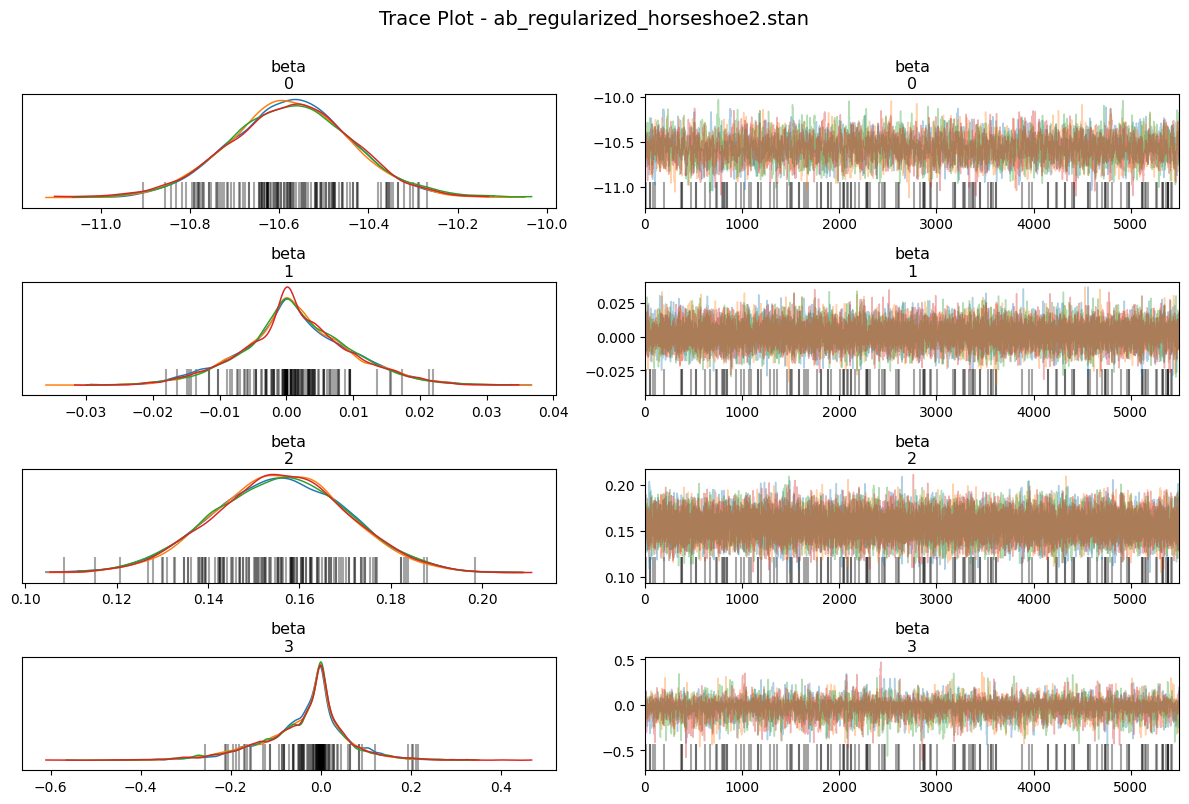

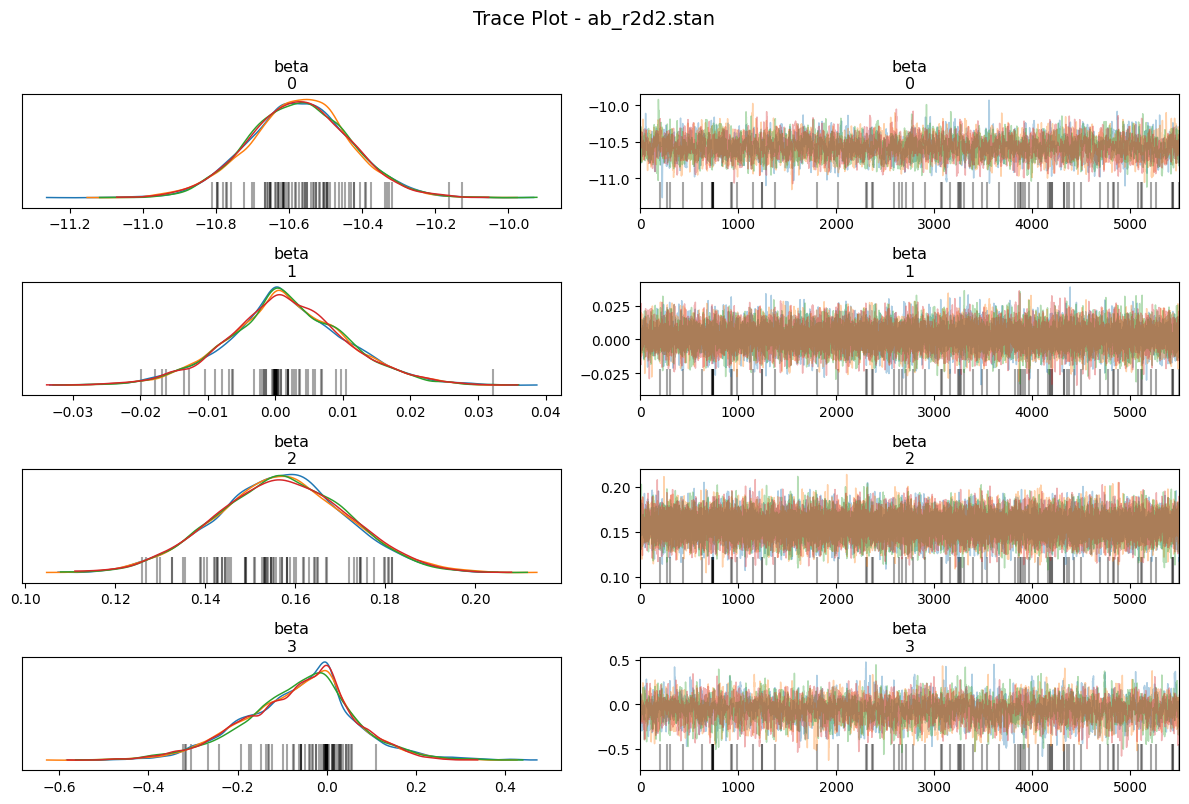

In [9]:
for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_trace(poi_glm_data, var_names=["beta"], compact=False)
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

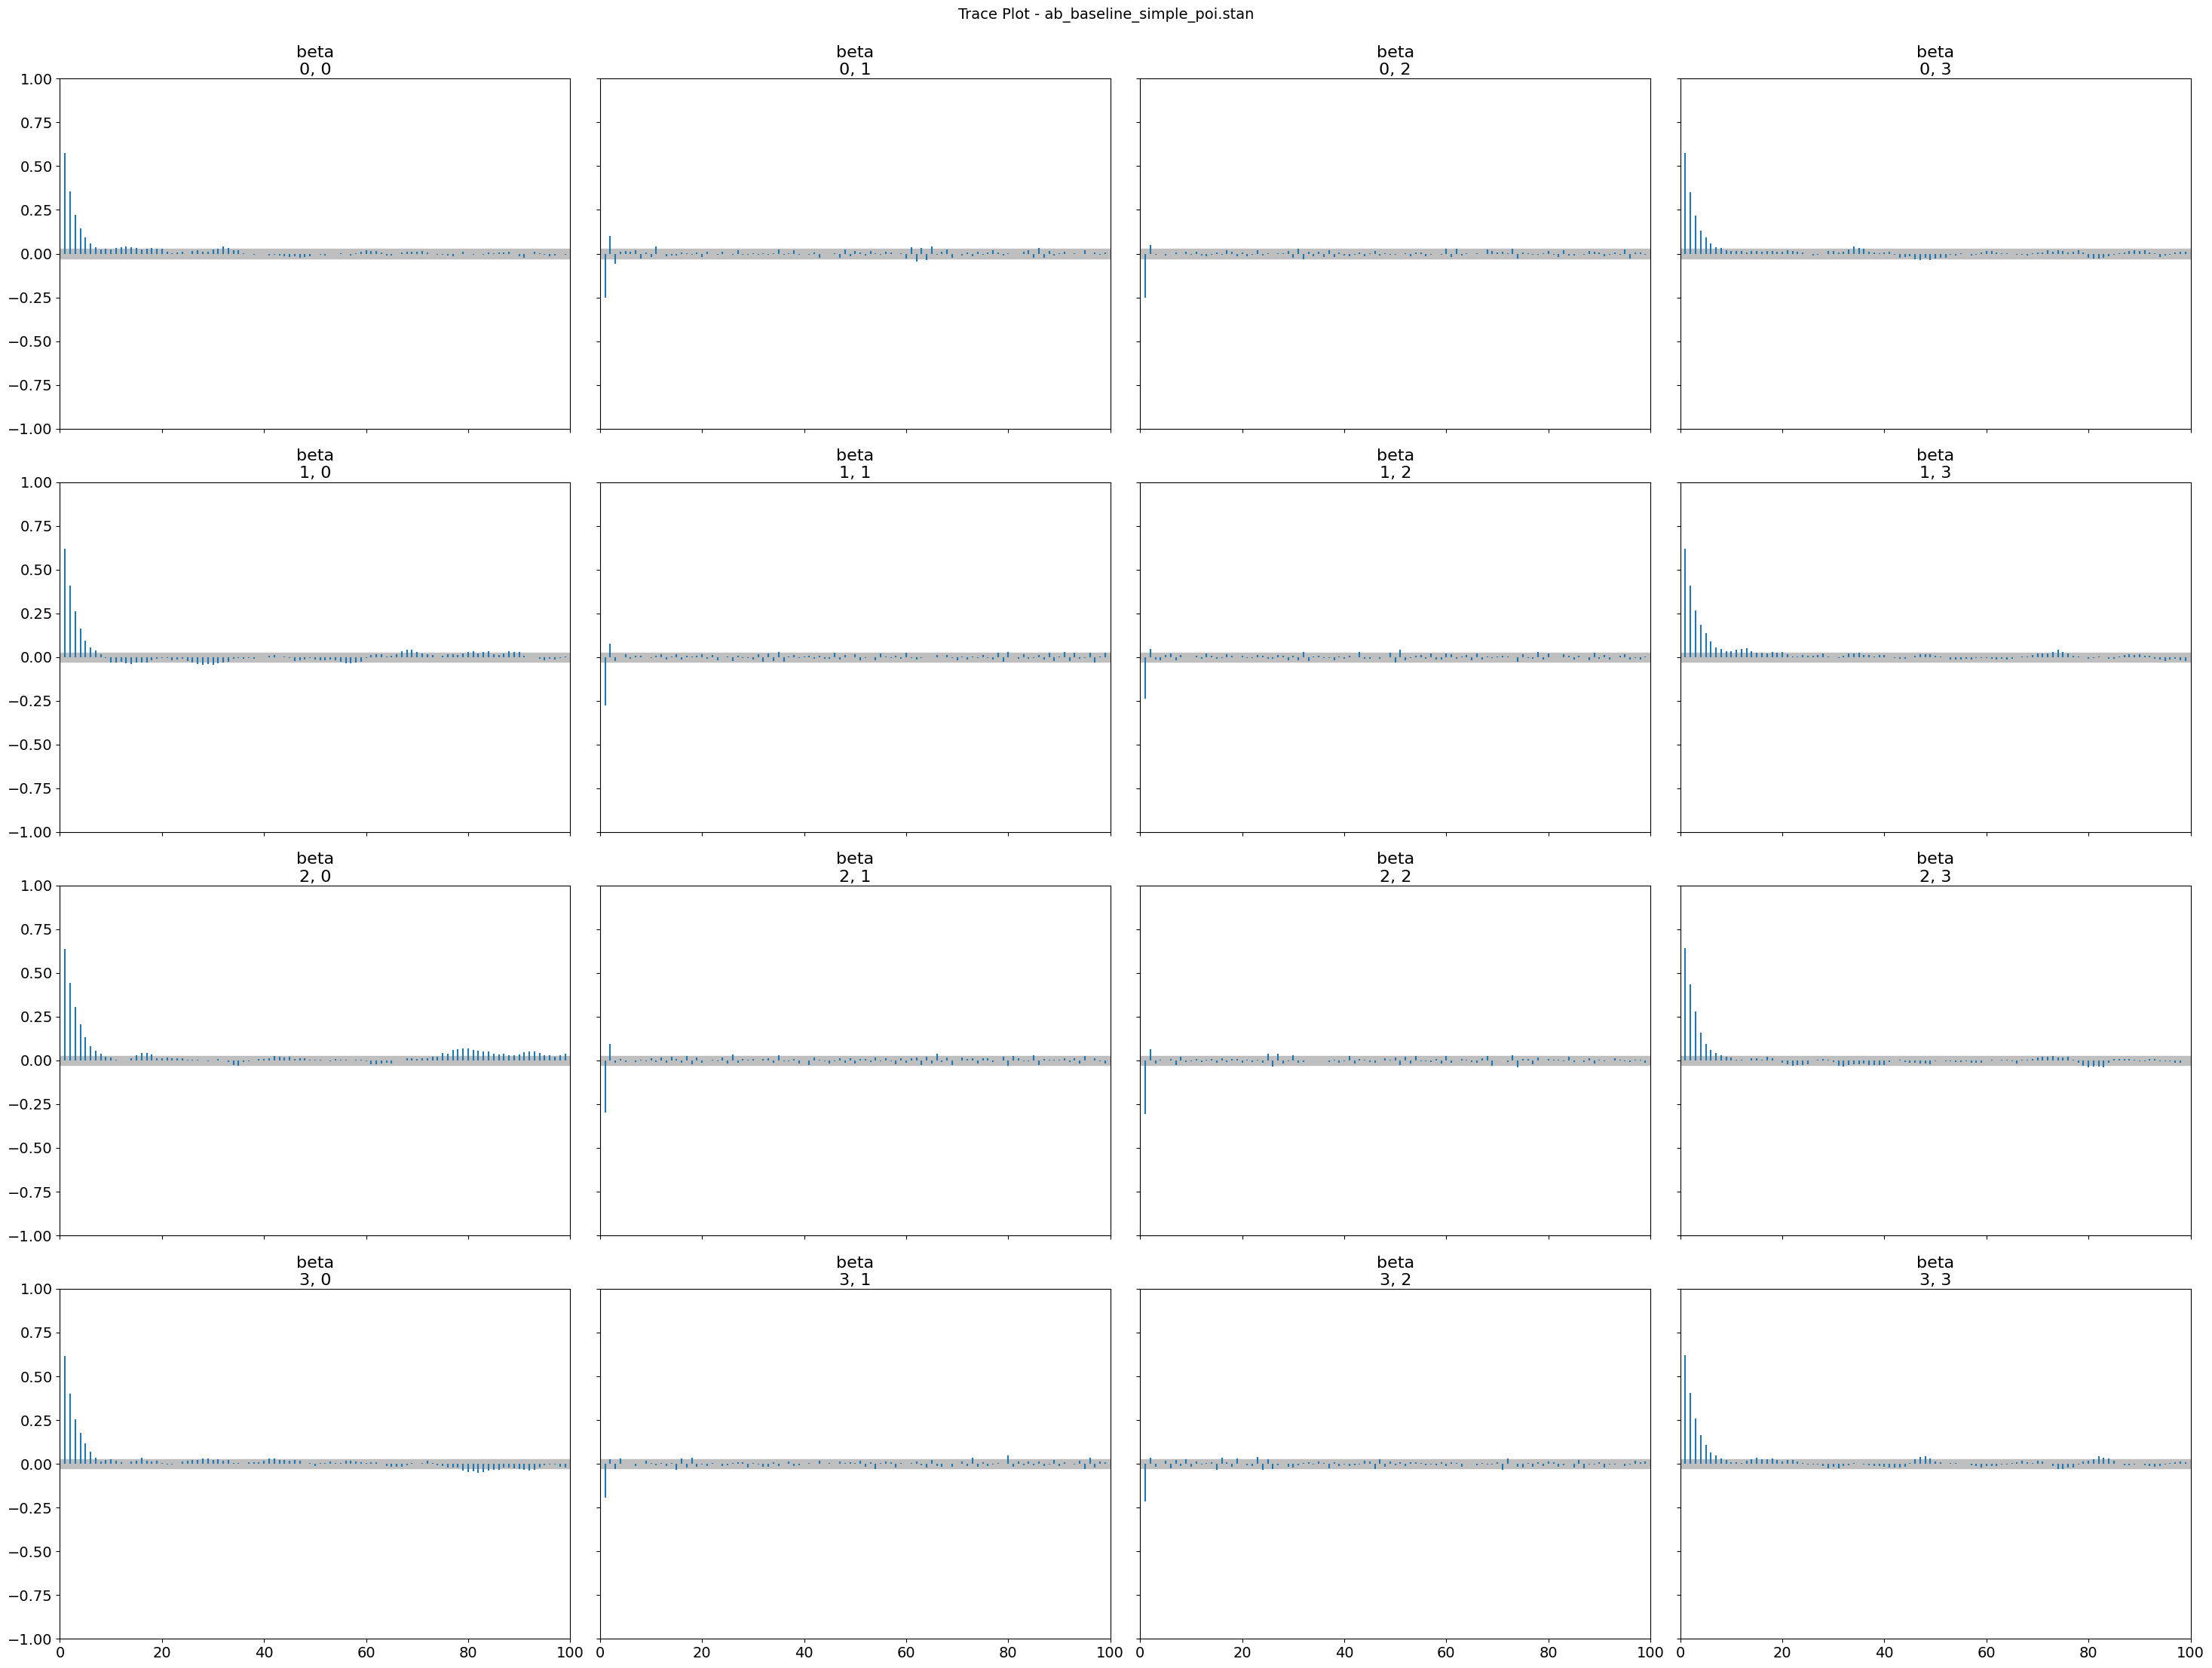

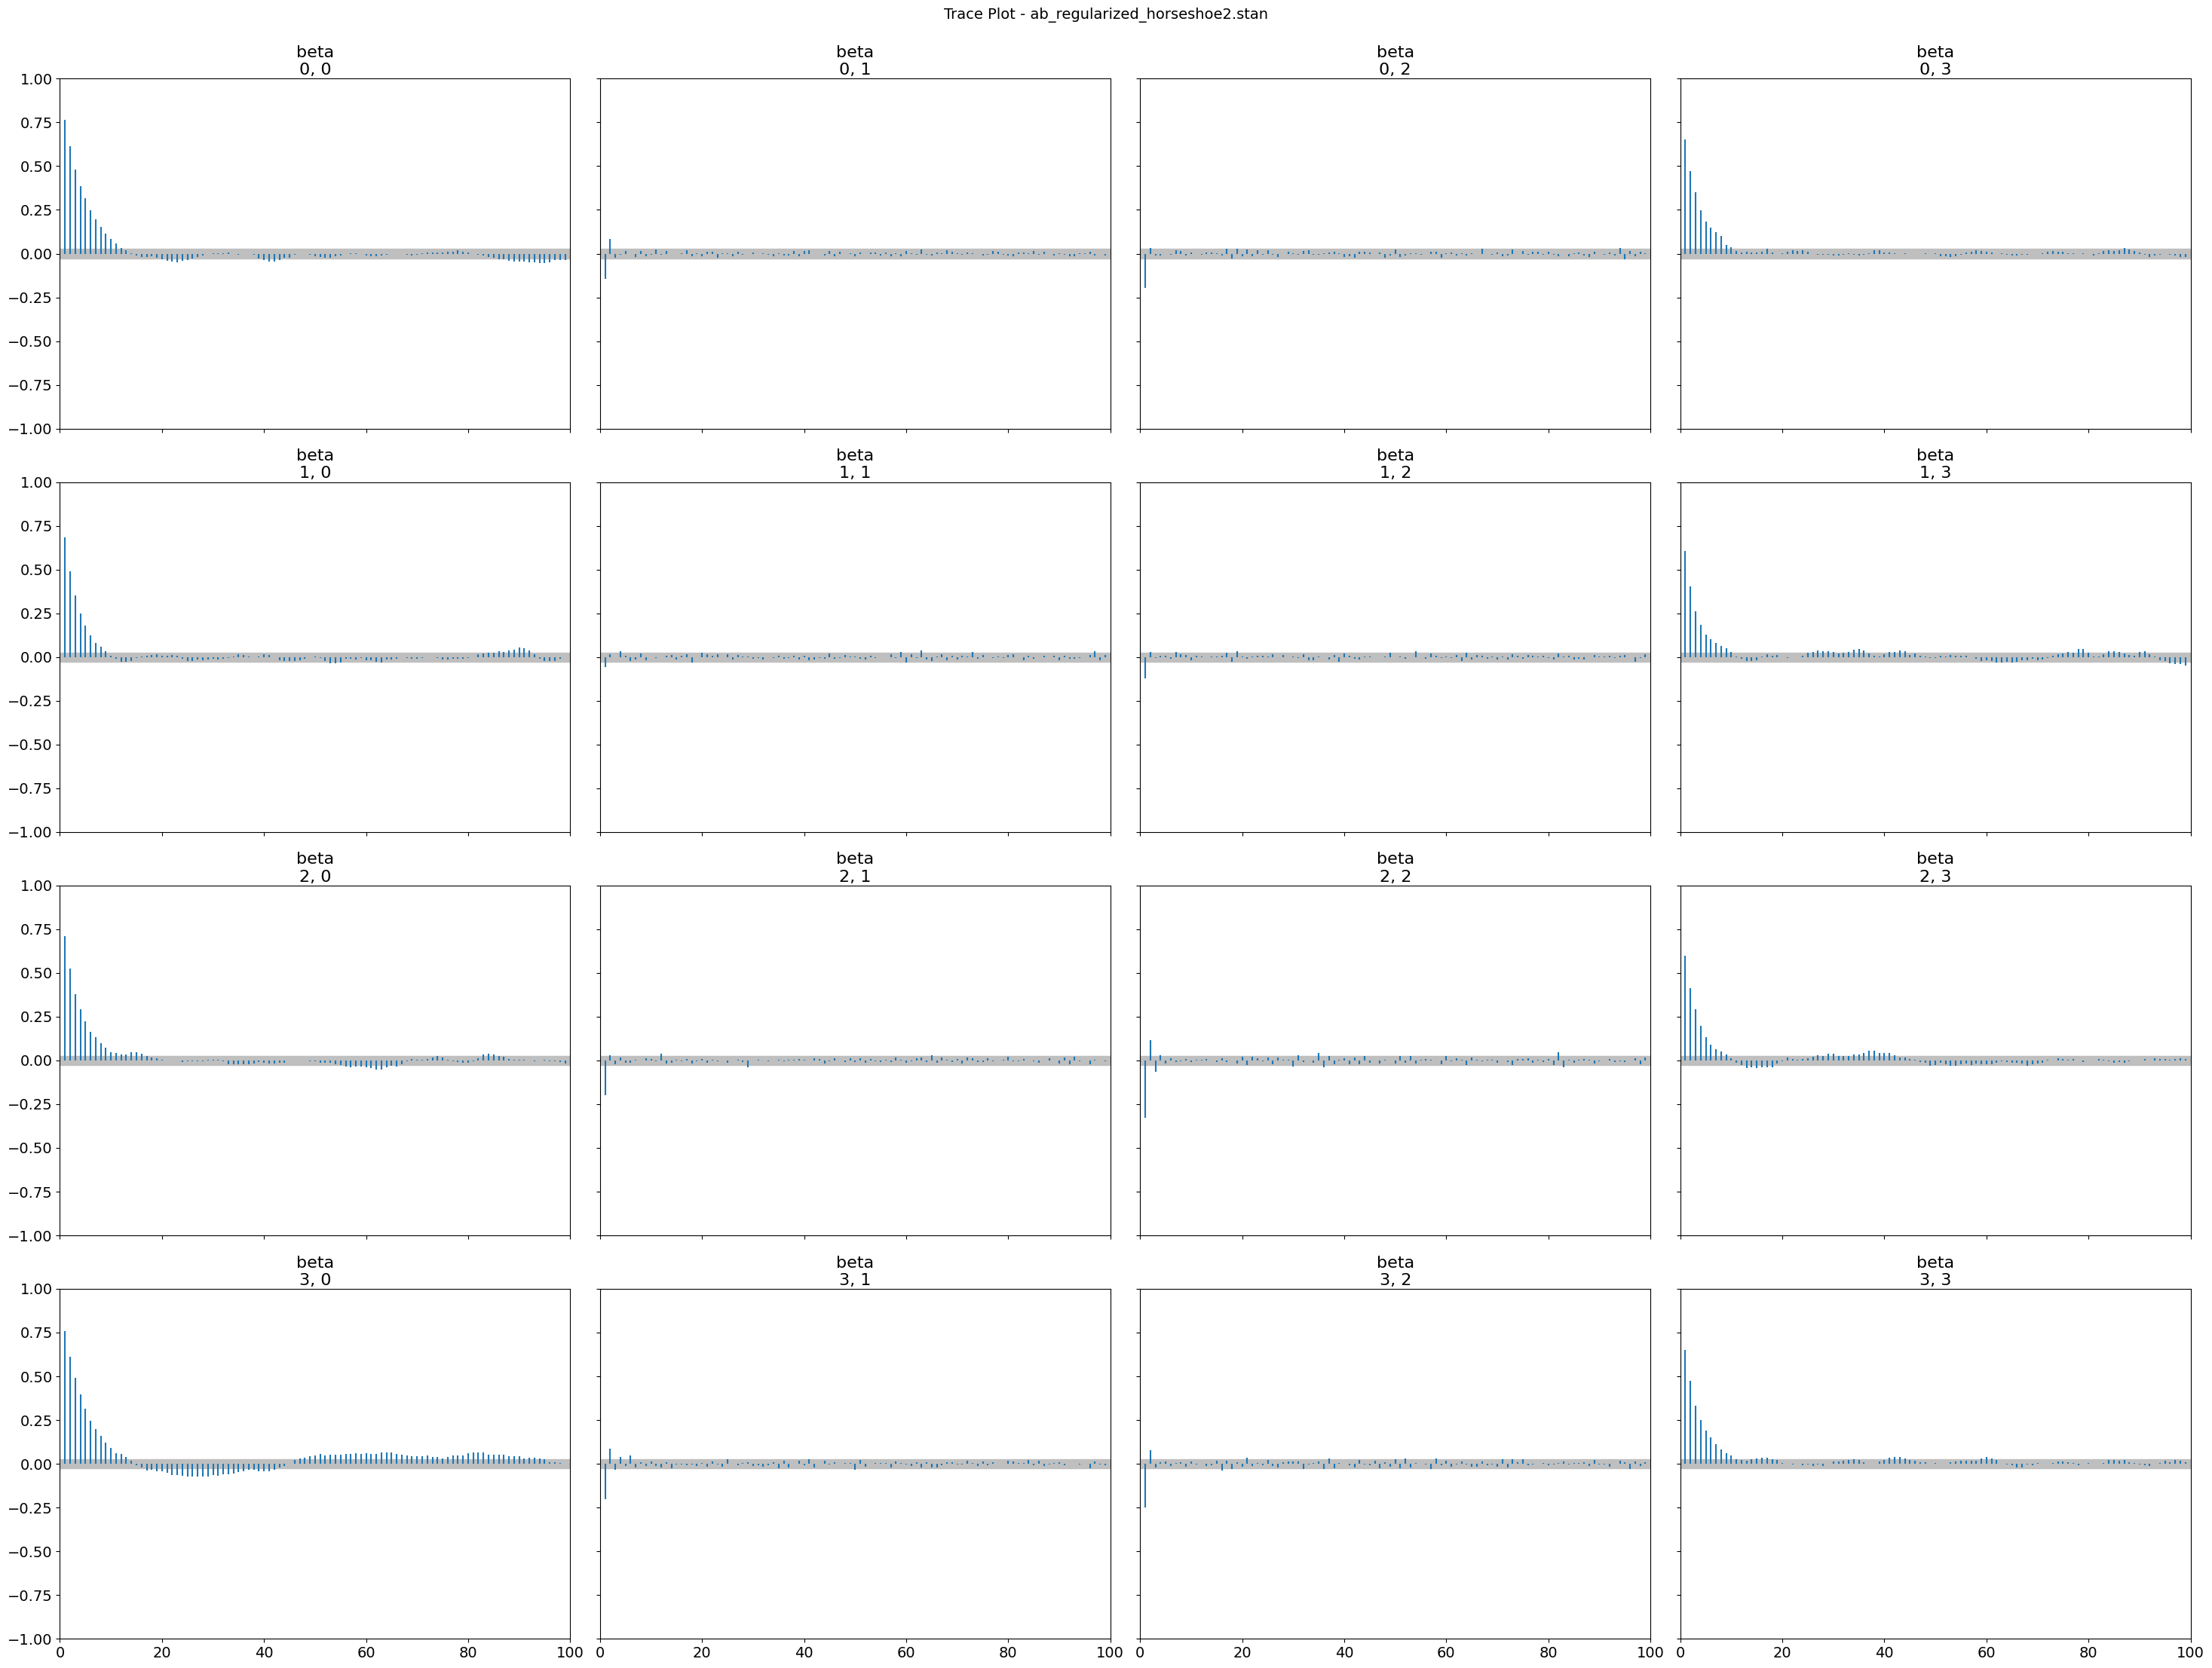

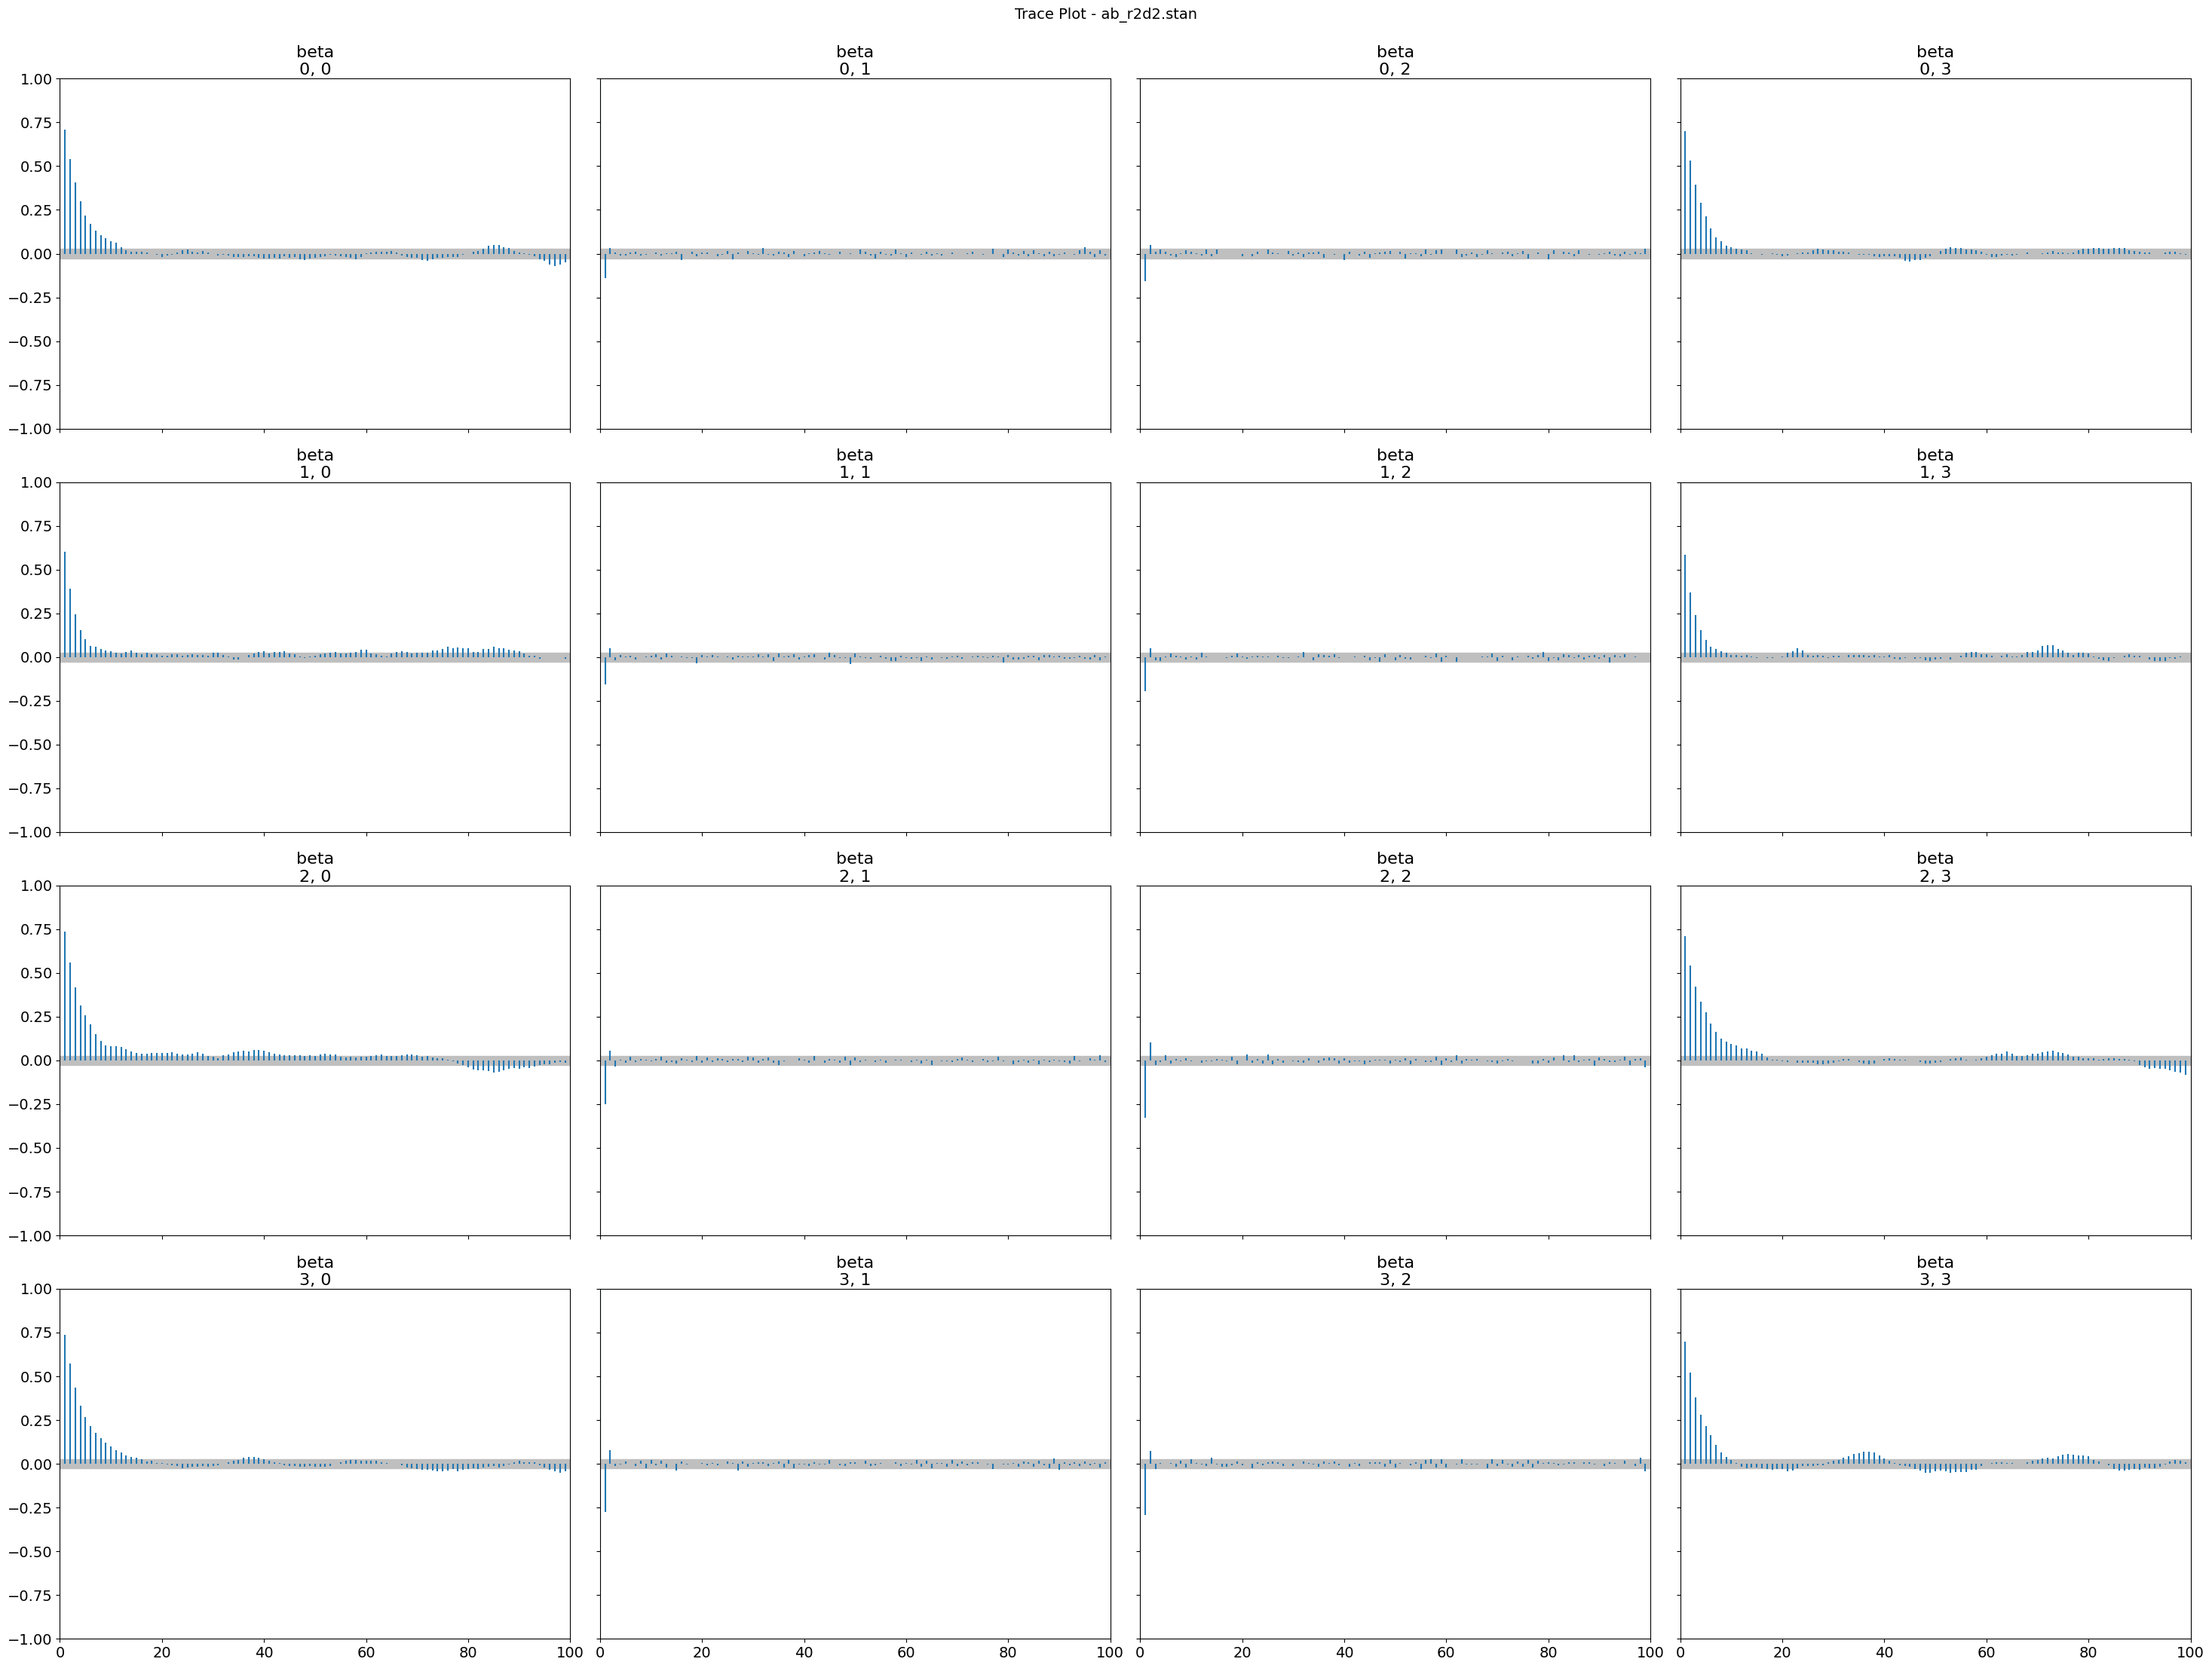

In [12]:

for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_autocorr(poi_glm_data, var_names=["beta"])
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show() 

In [13]:
model_names = list(models.keys())
models[model_names[0]]["fit"].summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68878.900000,0.052449,4.603990,4.541200,68870.900000,68879.200000,68885.800000,7762.61,12805.50,16.11830,1.000130
beta[1],-10.569400,0.001993,0.139734,0.135579,-10.797400,-10.570400,-10.335800,4917.85,7380.23,10.21140,1.001620
beta[2],0.001976,0.000051,0.009597,0.009574,-0.013817,0.001985,0.017815,35356.70,16341.30,73.41440,1.000120
beta[3],0.157414,0.000074,0.014502,0.014637,0.133592,0.157395,0.181074,38826.10,17062.20,80.61830,1.000450
beta[4],-0.084768,0.002089,0.141014,0.137467,-0.313622,-0.085217,0.146301,4574.54,7324.20,9.49855,1.000540
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.544210,0.001005,0.140611,0.096354,-2.826430,-2.496610,-2.421890,21827.80,19192.60,45.32310,0.999988
log_lik[375],-3.196330,0.002651,0.402993,0.392345,-3.924730,-3.149100,-2.622440,23357.40,18288.10,48.49920,0.999918
log_lik[376],-2.178800,0.000985,0.150503,0.150091,-2.430150,-2.175400,-1.937110,23357.40,18288.10,48.49920,0.999910
log_lik[377],-1.402410,0.000533,0.081464,0.081023,-1.542190,-1.398190,-1.275910,23357.50,18288.10,48.49930,0.999912


In [ ]:
glm_fit = models[model_names[1]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68885.000000,0.060222,4.960340,4.896290,68876.200000,68885.300000,68892.500000,6875.84,11576.60,7.07474,1.00092
beta[1],-10.573200,0.002364,0.138450,0.137143,-10.802400,-10.572900,-10.345800,3435.41,6094.45,3.53479,1.00134
beta[2],0.001396,0.000049,0.008114,0.007019,-0.011957,0.000879,0.015239,27455.00,14566.50,28.24920,1.00059
beta[3],0.155643,0.000081,0.014585,0.014443,0.131557,0.155711,0.179502,32356.50,15347.00,33.29250,1.00007
beta[4],-0.030153,0.001396,0.087983,0.054292,-0.197932,-0.011372,0.089935,4749.55,4909.43,4.88694,1.00044
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.543650,0.001006,0.138600,0.096006,-2.826730,-2.496590,-2.421870,22663.20,17380.10,23.31880,1.00022
log_lik[375],-3.198850,0.002620,0.396799,0.383941,-3.925470,-3.152300,-2.633610,23105.50,17380.10,23.77390,1.00026
log_lik[376],-2.180280,0.000972,0.147816,0.146385,-2.430360,-2.176610,-1.943480,23105.50,17380.10,23.77390,1.00023
log_lik[377],-1.403130,0.000527,0.080080,0.079178,-1.542320,-1.398840,-1.279000,23105.50,17380.10,23.77390,1.00024


: 

: 

In [ ]:
glm_fit = models[model_names[2]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68884.600000,0.058484,4.908940,4.851070,68875.900000,68885.000000,68892.000000,7111.53,11330.50,9.59496,1.00052
beta[1],-10.578000,0.002681,0.141305,0.135344,-10.811100,-10.577700,-10.347600,2756.56,4355.11,3.71918,1.00241
beta[2],0.001433,0.000052,0.008199,0.007264,-0.011972,0.000845,0.015584,25533.70,15474.50,34.45040,1.00031
beta[3],0.156000,0.000079,0.014530,0.014557,0.131779,0.156012,0.179812,33853.00,16662.10,45.67480,1.00021
beta[4],-0.037294,0.001659,0.097677,0.067484,-0.221650,-0.017709,0.101137,3967.22,4601.73,5.35262,1.00164
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.544280,0.001014,0.140186,0.096400,-2.827950,-2.496250,-2.421820,21557.40,17777.30,29.08540,1.00007
log_lik[375],-3.199750,0.002657,0.400011,0.389230,-3.927830,-3.150960,-2.633380,23116.40,17719.70,31.18890,1.00004
log_lik[376],-2.180480,0.000978,0.148655,0.148452,-2.431050,-2.176100,-1.943350,23116.40,17719.70,31.18890,1.00004
log_lik[377],-1.403260,0.000531,0.080599,0.079993,-1.542730,-1.398570,-1.278940,23116.40,17719.70,31.18890,1.00004


: 

: 

In [ ]:
glm_fit = models[model_names[3]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68883.800000,0.057433,4.876840,4.748770,68875.300000,68884.200000,68891.300000,7280.09,11976.60,8.73213,1.000030
beta[1],-10.570200,0.002445,0.141054,0.138377,-10.801900,-10.571200,-10.338800,3342.86,5247.76,4.00961,1.001150
beta[2],0.001508,0.000050,0.008517,0.007694,-0.012338,0.000988,0.016127,29051.20,14697.50,34.84560,0.999999
beta[3],0.156370,0.000076,0.014522,0.014380,0.132316,0.156420,0.180413,36443.70,15931.40,43.71250,1.000460
beta[4],-0.044992,0.001703,0.105237,0.080929,-0.239784,-0.026272,0.106677,4204.44,5721.02,5.04303,1.001210
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.543430,0.001012,0.140315,0.096070,-2.825360,-2.496150,-2.421810,22824.20,17742.00,27.37660,1.000240
log_lik[375],-3.196100,0.002632,0.400336,0.388574,-3.922830,-3.150310,-2.626290,23143.70,16996.40,27.75980,1.000330
log_lik[376],-2.178990,0.000978,0.149114,0.148156,-2.429590,-2.175860,-1.939320,23143.70,16996.40,27.75980,1.000350
log_lik[377],-1.402470,0.000529,0.080781,0.079929,-1.541870,-1.398440,-1.276980,23143.70,16996.40,27.75980,1.000340


: 

: 

In [ ]:
glm_fit = models[model_names[4]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68884.500000,0.052094,4.552970,4.432970,68876.400000,68884.800000,68891.400000,7662.58,12563.40,10.83330,1.00017
beta[1],-10.576400,0.002157,0.139936,0.134591,-10.805900,-10.578600,-10.344800,4203.48,6634.30,5.94282,1.00091
beta[2],0.001945,0.000051,0.009496,0.009474,-0.013723,0.001902,0.017622,35549.50,16540.50,50.25950,1.00007
beta[3],0.157241,0.000082,0.014554,0.014546,0.133161,0.157270,0.181172,31529.90,17450.40,44.57660,1.00011
beta[4],-0.080644,0.002313,0.139675,0.136405,-0.309660,-0.079471,0.148074,3644.79,6204.88,5.15296,1.00059
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.542430,0.001000,0.138093,0.096046,-2.821370,-2.496320,-2.421780,21843.10,17679.80,30.88140,1.00002
log_lik[375],-3.194350,0.002666,0.396884,0.385072,-3.915110,-3.149960,-2.629400,22167.60,16587.20,31.34030,1.00003
log_lik[376],-2.178520,0.000994,0.148084,0.147811,-2.427330,-2.175730,-1.941090,22167.60,16587.20,31.34030,1.00003
log_lik[377],-1.402190,0.000538,0.080186,0.079560,-1.540540,-1.398360,-1.277840,22167.60,16587.20,31.34030,1.00003


: 

: 

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

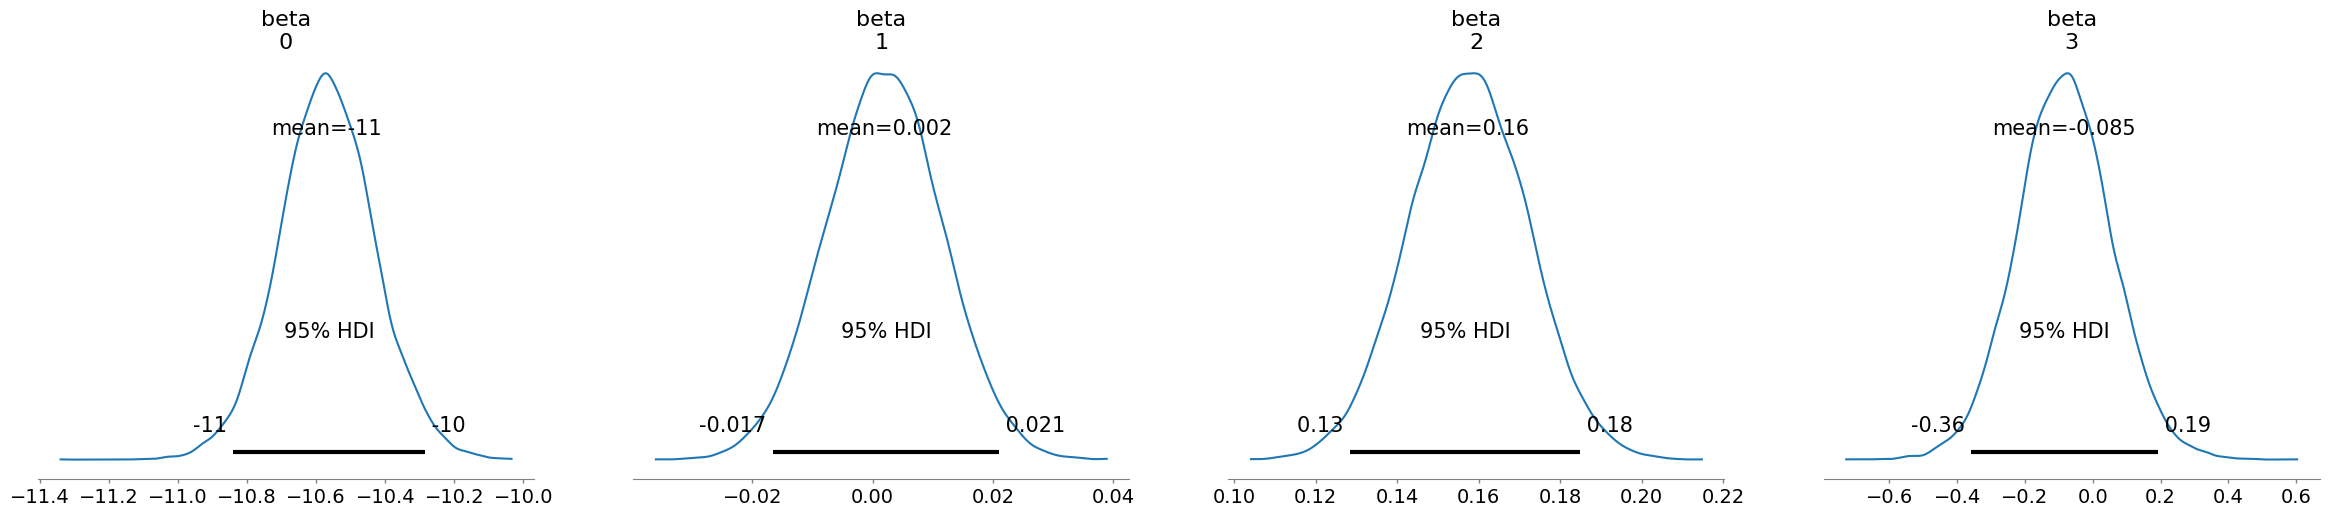

In [15]:
az.plot_posterior(models[model_names[0]]["fit"], var_names=["beta"], hdi_prob=0.95)

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

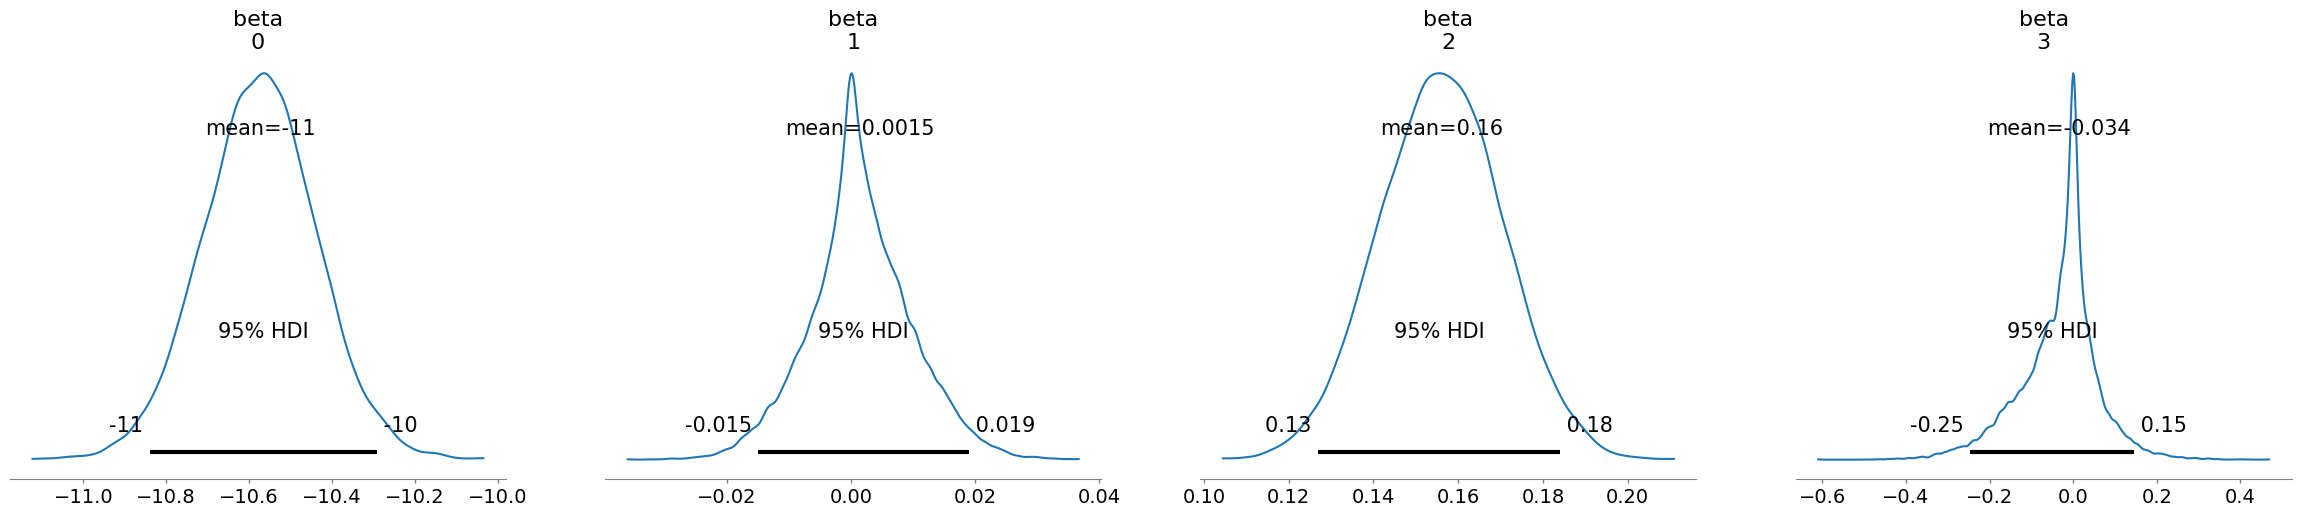

In [16]:
az.plot_posterior(models[model_names[1]]["fit"], var_names=["beta"], hdi_prob=0.95)

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

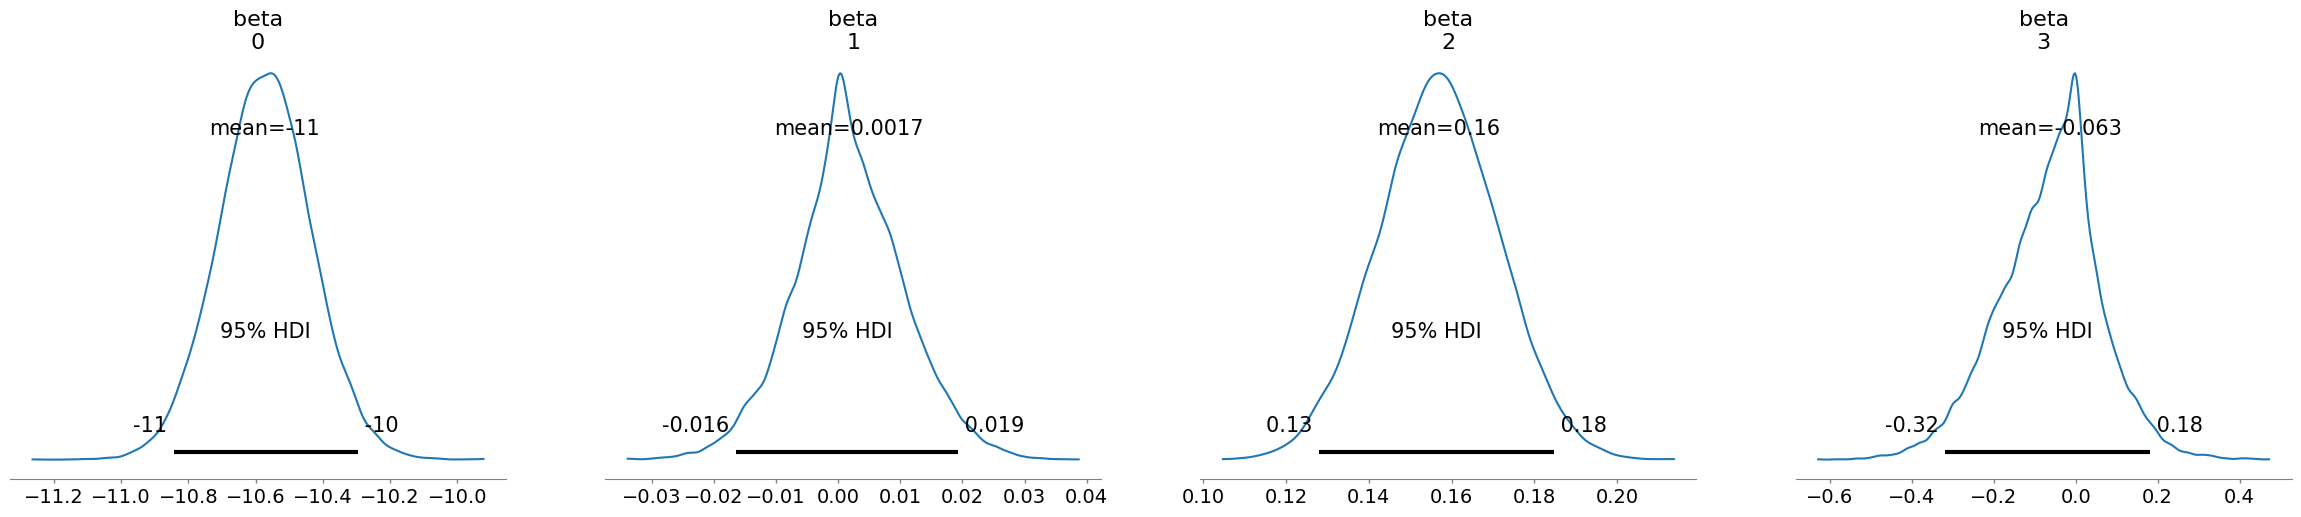

In [17]:
az.plot_posterior(models[model_names[2]]["fit"], var_names=["beta"], hdi_prob=0.95)

In [18]:
az.plot_posterior(models[model_names[3]]["fit"], var_names=["beta"], hdi_prob=0.95)

IndexError: list index out of range

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

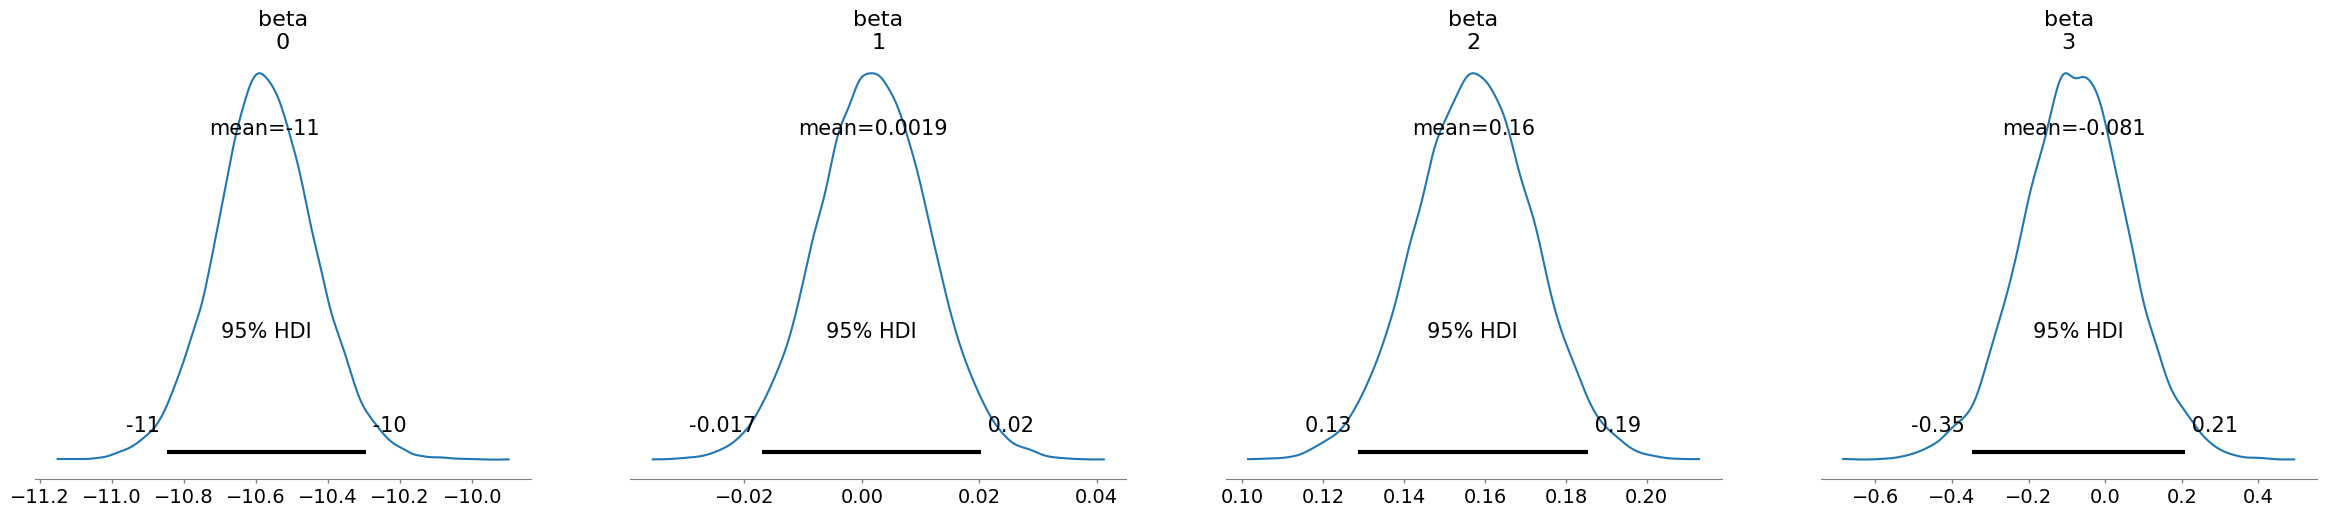

: 

: 

In [ ]:
az.plot_posterior(models[model_names[4]]["fit"], var_names=["beta"], hdi_prob=0.95)

In [ ]:
def plot_confident_intervals(model_fit, var_name="beta"):
    
    sum_beta = az.summary(model_fit, var_names=[var_name], hdi_prob=0.95)
    names = sum_beta.index.to_list()[1:]
    mean  = sum_beta["mean"].values[1:]
    low   = sum_beta["hdi_2.5%"].values[1:]
    high  = sum_beta["hdi_97.5%"].values[1:]
    y = np.arange(len(names))

# Generate colors based on array length
    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    plt.figure(figsize=(6, 3))
    for i in range(len(names)):
        plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
        plt.plot(mean[i], y[i], "o", color=colors[i])

    plt.axvline(0, color="black", ls="--", alpha=0.7)
    plt.yticks(y, names)
    plt.xlabel("beta (log scale effect)")
    plt.title("Posterior 95% HDI — beta")
    plt.tight_layout()
    plt.show()

: 

: 

ab_baseline_simple_poi.stan


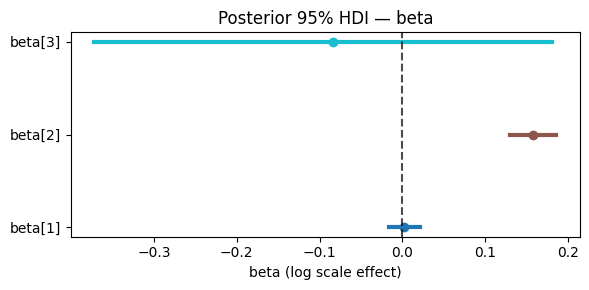

ab_regularized_horseshoe1.stan


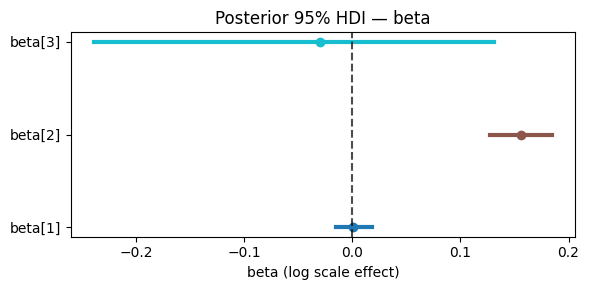

ab_regularized_horseshoe2.stan


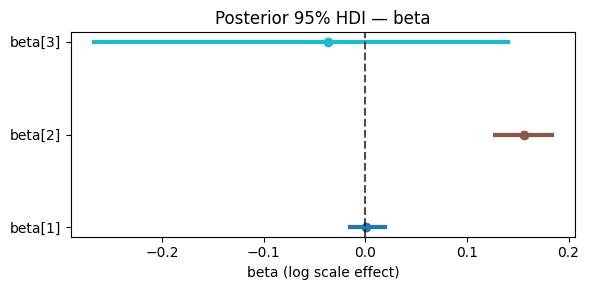

ab_regularized_horseshoe3.stan


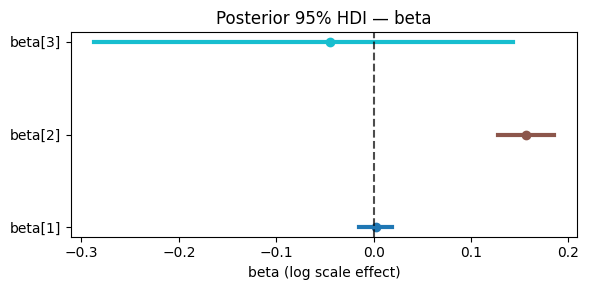

ab_lasso.stan


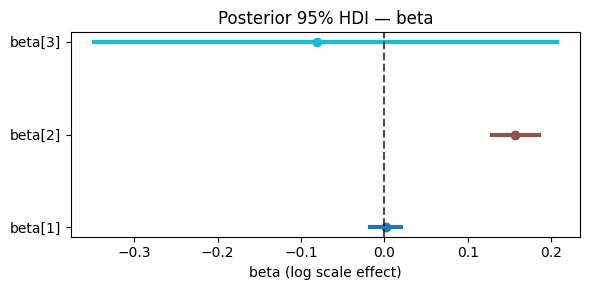

ab_horseshoe.stan


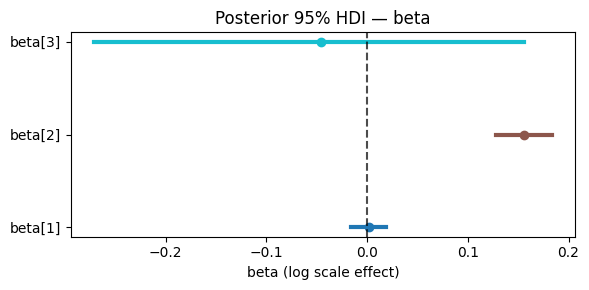

ab_r2d2.stan


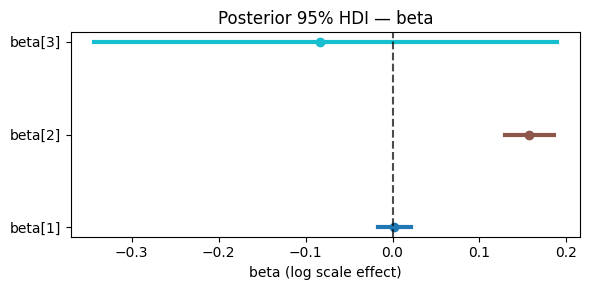

: 

: 

In [ ]:
for i in model_names:
    print(i)
    plot_confident_intervals(models[i]["fit"], var_name="beta")

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/py


=== LOO COMPARISON ===
                                rank     elpd_loo       p_loo  elpd_diff  \
ab_regularized_horseshoe2.stan     0 -1607.727105  108.996432   0.000000   
ab_regularized_horseshoe3.stan     1 -1607.926702  109.205142   0.199597   
ab_regularized_horseshoe1.stan     2 -1607.993223  109.450548   0.266118   
ab_lasso.stan                      3 -1608.653949  110.139945   0.926844   
ab_r2d2.stan                       4 -1609.094232  110.739636   1.367127   
ab_horseshoe.stan                  5 -1609.248165  110.735643   1.521060   
ab_baseline_simple_poi.stan        6 -1609.354964  110.925855   1.627859   

                                      weight         se       dse  warning  \
ab_regularized_horseshoe2.stan  1.000000e+00  82.953261  0.000000     True   
ab_regularized_horseshoe3.stan  3.885781e-16  83.009150  0.557032     True   
ab_regularized_horseshoe1.stan  1.057960e-15  83.071836  0.596339     True   
ab_lasso.stan                   0.000000e+00  83.103138

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


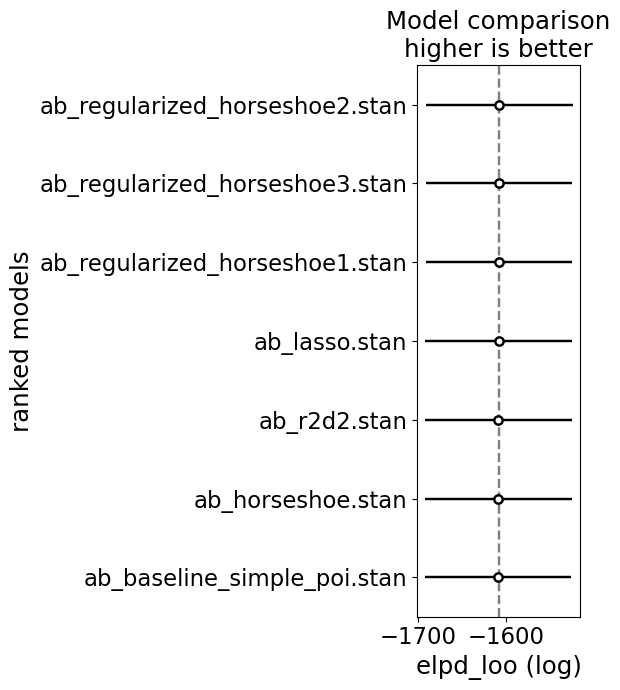

: 

: 

In [ ]:
compare_dict = {
}
for key in models:
    compare_dict[key] = models[key]["az"]

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/a


=== WAIC COMPARISON ===
                                rank    elpd_waic      p_waic  elpd_diff  \
ab_regularized_horseshoe1.stan     0 -1605.491978  106.949303   0.000000   
ab_regularized_horseshoe3.stan     1 -1605.826618  107.105058   0.334640   
ab_regularized_horseshoe2.stan     2 -1605.875838  107.145165   0.383860   
ab_horseshoe.stan                  3 -1606.312147  107.799625   0.820169   
ab_lasso.stan                      4 -1606.628110  108.114106   1.136132   
ab_r2d2.stan                       5 -1606.654858  108.300263   1.162881   
ab_baseline_simple_poi.stan        6 -1606.733079  108.303970   1.241101   

                                      weight         se       dse  warning  \
ab_regularized_horseshoe1.stan  1.000000e+00  82.793147  0.000000     True   
ab_regularized_horseshoe3.stan  0.000000e+00  82.856676  0.376197     True   
ab_regularized_horseshoe2.stan  0.000000e+00  82.865935  0.367396     True   
ab_horseshoe.stan               9.972517e-16  82.93029

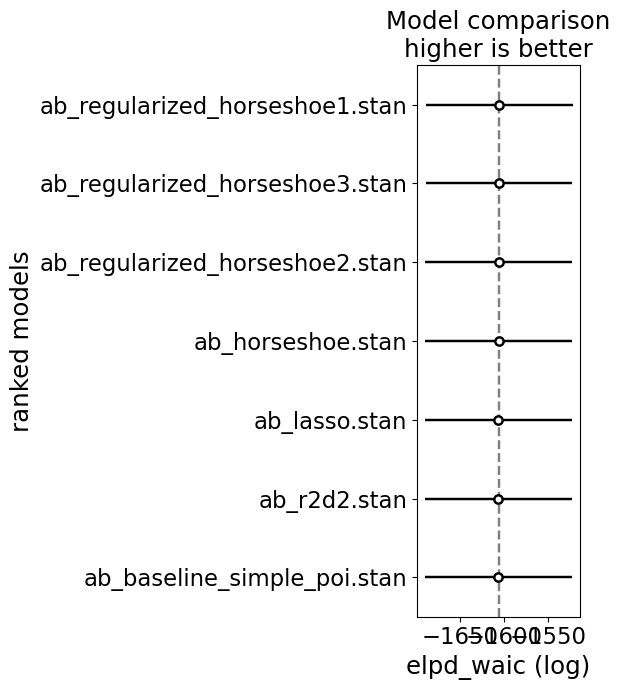

: 

: 

In [ ]:
comparison_waic = az.compare(compare_dict, ic="waic")
print("\n=== WAIC COMPARISON ===")
print(comparison_waic)

az.plot_compare(comparison_waic, insample_dev=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def select_by_hdi(az_data, var_name="beta", credible_mass=0.95, 
                  covariate_names=["Intercept", "IBU", "DMSO", "Temp"]):
    summary = az.summary(az_data, var_names=[var_name], 
                        hdi_prob=credible_mass)
    
    results = []
    for idx, name in enumerate(covariate_names):
        row = summary.iloc[idx]
        hdi_low = row[f"hdi_{(1-credible_mass)/2*100:.1f}%"]
        hdi_high = row[f"hdi_{(1+credible_mass)/2*100:.1f}%"]
        
        crosses_zero = (hdi_low < 0) and (hdi_high > 0)
        
        results.append({
            'variable': name,
            'mean': row['mean'],
            'hdi_low': hdi_low,
            'hdi_high': hdi_high,
            'crosses_zero': crosses_zero,
            'selected': not crosses_zero
        })
    
    return pd.DataFrame(results)

print("=" * 40)
print("HDI-BASED SELECTION (95% credible intervals)")
print("=" * 40)

for model_name in model_names:
    print(f"\n{model_name}:")
    result = select_by_hdi(az_data=models[model_name]["az"], credible_mass=0.95)
    # print(result)
    print(f"Selected: {result[result['selected']]['variable'].tolist()}")

HDI-BASED SELECTION (95% credible intervals)

ab_baseline_simple_poi.stan:
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe1.stan:
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe2.stan:
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe3.stan:
Selected: ['Intercept', 'DMSO']

ab_lasso.stan:
Selected: ['Intercept', 'DMSO']

ab_horseshoe.stan:
Selected: ['Intercept', 'DMSO']

ab_r2d2.stan:
Selected: ['Intercept', 'DMSO']


: 

: 

In [ ]:
def posterior_inclusion_probability(az_data, var_name="beta", 
                                   threshold=None,
                                   covariate_names=["Intercept", "IBU", "DMSO", "Temp"], prob=0.5):
    """
    Calculate P(|beta_j| > threshold | data)
    
    If threshold is None, uses practical significance = 0.1 * posterior SD for each variable
    (Rule of thumb: effects smaller than 10% of SD are negligible)
    """
    samples = az_data.posterior[var_name].values
    n_chains, n_draws, p = samples.shape
    
    results = []
    for j in range(p):
        beta_j = samples[:, :, j].flatten()
        
        if threshold is None:
            thresh = 0.1 * np.std(beta_j)
        else:
            thresh = threshold
        
        pip = np.mean(np.abs(beta_j) > thresh)
        
        prob_positive = np.mean(beta_j > thresh)
        prob_negative = np.mean(beta_j < -thresh)
        
        results.append({
            'variable': covariate_names[j],
            'threshold_used': thresh,
            'PIP': pip,
            'P(β > thresh)': prob_positive,
            'P(β < -thresh)': prob_negative,
            'median': np.median(beta_j),
            'sd': np.std(beta_j),
            'selected': pip > prob  
        })
    
    return pd.DataFrame(results)

print("\n" + "=" * 60)
print("POSTERIOR INCLUSION PROBABILITY")
print("=" * 60)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("\n--- Auto threshold (10% of posterior SD) ---")
    result = posterior_inclusion_probability(az_data=models[model_name]["az"], prob=0.8)
    #print(result[['variable', 'threshold_used', 'PIP', 'median', 'sd', 'selected']])
    print(f"Selected (PIP > 0.8): {result[result['selected']]['variable'].tolist()}")
    
    print("\n--- Fixed threshold = 0.1 (practical significance) ---")
    result_fixed = posterior_inclusion_probability(
        models[model_name]["az"],
        threshold=0.1, prob=0.8
    )
    #print(result_fixed[['variable', 'PIP', 'median', 'selected']])
    print(f"Selected: {result_fixed[result_fixed['selected']]['variable'].tolist()}")


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe1.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe2.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

ab_regularized_horseshoe3.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

ab_lasso.stan:

--- Auto threshold (10% of posterior SD) ---
Sele

: 

: 

In [ ]:
def cross_model_selection(models_dict, model_names, 
                         covariate_names=["Intercept", "IBU", "DMSO", "Temp"],
                         methods=['hdi', 'pip'], pip_th = None, pip_prob=0.5):
    """
    Variable selected if chosen by majority of models
    """
    selection_matrix = []
    
    for model_name in model_names:
        for method in methods:
            if method == 'hdi':
                result = select_by_hdi(models_dict[model_name]["az"], 
                                      covariate_names=covariate_names)
            if method == 'pip':
                result = posterior_inclusion_probability(
        models_dict[model_name]["az"],
        threshold=pip_th, prob=pip_prob
    )   
            selection_matrix.append(result['selected'].values)
    
    selection_matrix = np.array(selection_matrix)
    
    selection_count = selection_matrix.sum(axis=0)
    
    consensus_df = pd.DataFrame({
        'variable': covariate_names,
        'n_models_selected': selection_count,
        'proportion': selection_count / (len(model_names) * len(methods)),
        'consensus_selected': selection_count >= (len(model_names) * len(methods) / 2)
    })
    
    return consensus_df

working_models = model_names

print("\n" + "=" * 60)
print("CROSS-MODEL CONSENSUS")
print("=" * 60)


CROSS-MODEL CONSENSUS


: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi', 'pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                 14    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                 14    1.000000                True
3       Temp                  5    0.357143               False

Final selection: ['Intercept', 'DMSO']


: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi'])
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  7         1.0                True
2       DMSO                  7         1.0                True
3       Temp                  7         1.0                True

Final selection: ['Intercept', 'IBU', 'DMSO', 'Temp']


: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8, pip_th=0.1)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                  7    1.000000                True
3       Temp                  5    0.714286                True

Final selection: ['Intercept', 'DMSO', 'Temp']


: 

: 


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.583636  0.416364      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.267955  0.732045      True
Selected (PIP > 0.5): ['Intercept', 'IBU', 'DMSO', 'Temp']

ab_regularized_horseshoe1.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.564227  0.435773      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.376682  0.623318      True
Selected (PIP > 0.5): ['Intercept', 'IBU', 'DMSO', 'Temp']

ab_regularized_horseshoe2.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.563091  0.436909      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.363000  0.637000      True
Selected (PIP > 0.5): ['Intercept

: 

: 

# comparison_loo 
very expensive -> I need to fit the sample with removing each covariate -> does not make sense. I will include only two covariate to see which one is better (TEMP, DMSO)